<a href="https://colab.research.google.com/github/ardominguezm/painting-geometry/blob/multiscale-corpus-analysis/notebooks/01_corpus_ablation_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiscale Geometry of Paintings — Corpus Ablation Study

This notebook executes the first decisive experiment for the revised project.

**Scientific question**

> Does multiscale luminance level-set curvature add independent, interpretable information about artistic style beyond conventional edge and texture descriptors?

We compare six controlled feature sets on the same train/test split:

| Experiment | Features |
|---|---|
| E1 | edges |
| E2 | GLCM texture |
| E3 | multiscale curvature |
| E4 | curvature + orientation/coherence |
| E5 | edges + texture (conventional baseline) |
| E6 | edges + texture + geometry |

The primary quantity is

\[
\Delta F_1 = F_1^{macro}(E6)-F_1^{macro}(E5).
\]

A paired, class-stratified bootstrap is used for the confidence interval of this difference.

**Important interpretation rule:** this notebook computes the **curvature of luminance level sets**, not Gaussian curvature of the graph \(z=I(x,y)\), and it does not assign psychological or emotional meaning to the descriptors.


## 1. Environment and repository

This cell installs the reproducible dependencies and checks out the research branch.


In [12]:
import os
os.chdir("/content")
print(os.getcwd())

/content


In [13]:
!pip -q install kagglehub statsmodels

import os, sys, subprocess, pathlib, shutil, json, time
from pathlib import Path

REPO_URL = "https://github.com/ardominguezm/painting-geometry.git"
BRANCH = "multiscale-corpus-analysis"
REPO_DIR = Path("/content/painting-geometry")

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

subprocess.run(["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, str(REPO_DIR)], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_DIR / "requirements.txt")], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))

print("Repository:", REPO_DIR)
print("Branch:", BRANCH)


Repository: /content/painting-geometry
Branch: multiscale-corpus-analysis


## 2. Download the same Impressionist corpus used in the previous pilot

The dataset is downloaded with `kagglehub`. The code below resolves the nested `training/training` and `validation/validation` structure automatically.


In [14]:
import kagglehub
from pathlib import Path

DATASET_ID = "delayedkarma/impressionist-classifier-data"
dataset_path = Path(kagglehub.dataset_download(DATASET_ID))
print("Dataset root:", dataset_path)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

def has_artist_folders(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    subdirs = [p for p in path.iterdir() if p.is_dir()]
    if len(subdirs) < 2:
        return False
    return any(
        any(f.is_file() and f.suffix.lower() in IMAGE_EXTS for f in d.rglob("*"))
        for d in subdirs[:5]
    )

def locate_split(base: Path, split: str) -> Path:
    candidates = [
        base / split / split,
        base / split,
        base,
    ]
    for c in candidates:
        if has_artist_folders(c):
            return c
    for c in base.rglob(split):
        if c.is_dir() and has_artist_folders(c):
            return c
    raise FileNotFoundError(f"Could not locate split '{split}' below {base}")

TRAIN_ROOT = locate_split(dataset_path, "training")
TEST_ROOT = locate_split(dataset_path, "validation")

print("TRAIN_ROOT:", TRAIN_ROOT)
print("TEST_ROOT :", TEST_ROOT)


Using Colab cache for faster access to the 'impressionist-classifier-data' dataset.
Dataset root: /kaggle/input/impressionist-classifier-data
TRAIN_ROOT: /kaggle/input/impressionist-classifier-data/training/training
TEST_ROOT : /kaggle/input/impressionist-classifier-data/validation/validation


## 3. Audit the corpus before feature extraction

This must be inspected before any model is fitted. We want to verify artist labels, sample sizes, and train/test support.


In [15]:
import pandas as pd
from collections import Counter

def split_inventory(root: Path):
    rows = []
    for artist_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        n = sum(
            1 for f in artist_dir.rglob("*")
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS
        )
        rows.append({"artist": artist_dir.name, "n_images": n})
    return pd.DataFrame(rows).sort_values("artist").reset_index(drop=True)

train_inventory = split_inventory(TRAIN_ROOT)
test_inventory = split_inventory(TEST_ROOT)

display(train_inventory.rename(columns={"n_images":"train_n"}).merge(
    test_inventory.rename(columns={"n_images":"test_n"}),
    on="artist", how="outer"
).fillna(0))

print("Total train:", int(train_inventory.n_images.sum()))
print("Total test :", int(test_inventory.n_images.sum()))


,artist,train_n,test_n
0,Cezanne,399,99
1,Degas,398,99
2,Gauguin,399,99
3,Hassam,399,99
4,Matisse,399,99
5,Monet,399,99
6,Pissarro,398,99
7,Renoir,399,99
8,Sargent,399,99
9,VanGogh,399,99


Total train: 3988
Total test : 990


## 4. Configuration

The first-pass analysis uses a long-side resolution of 512 px and four Gaussian scales. This mirrors the scale used in the earlier corpus pilot while introducing genuine multiscale curvature.

Set `RECOMPUTE_FEATURES = False` after the first successful run if you keep the Colab session alive.


In [28]:
LONG_SIDE = 512
SIGMAS = [1.0, 2.0, 4.0, 8.0]
MAX_PER_ARTIST = None
RECOMPUTE_FEATURES = True
RESULTS_DIR = REPO_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)


TRAIN_CSV = RESULTS_DIR / "features_train_multiscale.csv"
TEST_CSV = RESULTS_DIR / "features_test_multiscale.csv"
ABLATION_CSV = RESULTS_DIR / "ablation_results.csv"



## 5. Extract corpus-scale features

Feature names are explicitly namespaced:

- `edge__...`
- `texture__...`
- `orient__...`
- `curv__...`

This separation is essential for a valid ablation study.


In [29]:
#import subprocess, sys, time

# def run_extraction(root: Path, output: Path):
#     cmd = [
#         sys.executable, "scripts/extract_corpus_features.py",
#         "--root", str(root),
#         "--output", str(output),
#         "--long-side", str(LONG_SIDE),
#         "--sigmas", *[str(x) for x in SIGMAS],
#     ]
#     t0 = time.time()
#     subprocess.run(cmd, check=True)
#     print(f"Elapsed: {(time.time()-t0)/60:.1f} min")

# if RECOMPUTE_FEATURES or not TRAIN_CSV.exists():
#     run_extraction(TRAIN_ROOT, TRAIN_CSV)

# if RECOMPUTE_FEATURES or not TEST_CSV.exists():
#     run_extraction(TEST_ROOT, TEST_CSV)

# train_df = pd.read_csv(TRAIN_CSV)
# test_df = pd.read_csv(TEST_CSV)

# print("Train:", train_df.shape)
# print("Test :", test_df.shape)
# print("Feature columns:", train_df.shape[1] - 4)

import subprocess, sys, time

def run_extraction(root: Path, output: Path):
    cmd = [
        sys.executable, "-u",
        "scripts/extract_corpus_features.py",
        "--root", str(root),
        "--output", str(output),
        "--long-side", str(LONG_SIDE),
        "--sigmas", *[str(x) for x in SIGMAS],
    ]

    if MAX_PER_ARTIST is not None:
        cmd += ["--max-per-artist", str(MAX_PER_ARTIST)]

    print("Executing:")
    print(" ".join(cmd))
    print()

    t0 = time.time()

    subprocess.run(cmd, check=True)

    print(f"\nElapsed: {(time.time()-t0)/60:.1f} min")


if RECOMPUTE_FEATURES or not TRAIN_CSV.exists():
    run_extraction(TRAIN_ROOT, TRAIN_CSV)

if RECOMPUTE_FEATURES or not TEST_CSV.exists():
    run_extraction(TEST_ROOT, TEST_CSV)

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("Feature columns:", train_df.shape[1] - 4)

Executing:
/usr/bin/python3 -u scripts/extract_corpus_features.py --root /kaggle/input/impressionist-classifier-data/training/training --output /content/painting-geometry/results/features_train_multiscale.csv --long-side 512 --sigmas 1.0 2.0 4.0 8.0


Elapsed: 16.8 min
Executing:
/usr/bin/python3 -u scripts/extract_corpus_features.py --root /kaggle/input/impressionist-classifier-data/validation/validation --output /content/painting-geometry/results/features_test_multiscale.csv --long-side 512 --sigmas 1.0 2.0 4.0 8.0


Elapsed: 4.2 min
Train: (3988, 57)
Test : (990, 57)
Feature columns: 53


## 6. Sanity checks on extracted features

Before classification, inspect missingness and make sure all six feature families are present.


In [30]:
prefixes = ["edge__", "texture__", "orient__", "curv__"]
summary = []
for p in prefixes:
    cols = [c for c in train_df.columns if c.startswith(p)]
    summary.append({
        "family": p,
        "n_features": len(cols),
        "train_missing_pct": float(train_df[cols].isna().mean().mean()*100) if cols else None,
        "test_missing_pct": float(test_df[cols].isna().mean().mean()*100) if cols else None,
    })

display(pd.DataFrame(summary))


,family,n_features,train_missing_pct,test_missing_pct
0,edge__,4,0.0,0.0
1,texture__,5,0.0,0.0
2,orient__,4,0.0,0.0
3,curv__,40,0.0,0.0


## 7. Statistical screening of curvature features across artists

This is **not** used for feature selection in the classifier. It is a descriptive inferential check of whether curvature descriptors differ among artists. Benjamini–Hochberg FDR controls multiple testing.


In [31]:
import numpy as np
from src.statistics import kruskal_by_feature

curv_cols = [c for c in train_df.columns if c.startswith("curv__")]
kw = kruskal_by_feature(
    train_df[curv_cols].to_numpy(),
    train_df["artist"].to_numpy(),
    curv_cols,
)

kw_df = pd.DataFrame([{
    "feature": r.feature,
    "H": r.statistic,
    "p_value": r.p_value,
    "q_value": r.q_value,
} for r in kw]).sort_values(["q_value", "H"], ascending=[True, False])

display(kw_df.head(15))
kw_df.to_csv(RESULTS_DIR / "curvature_kruskal_fdr.csv", index=False)


,feature,H,p_value,q_value
9,curv__kappa_s1p0_grad_weighted_abs,1647.871234,0.000000e+00,0.000000e+00
11,curv__kappa_s2p0_p75_abs,1625.721681,0.000000e+00,0.000000e+00
14,curv__kappa_s2p0_mad_abs,1595.437962,0.000000e+00,0.000000e+00
12,curv__kappa_s2p0_p90_abs,1568.068939,0.000000e+00,0.000000e+00
10,curv__kappa_s2p0_median_abs,1556.854664,0.000000e+00,0.000000e+00
19,curv__kappa_s2p0_grad_weighted_abs,1539.988474,0.000000e+00,0.000000e+00
2,curv__kappa_s1p0_p90_abs,1384.224330,1.980058e-292,1.131461e-291
1,curv__kappa_s1p0_p75_abs,1382.974543,3.687182e-292,1.843591e-291
13,curv__kappa_s2p0_p95_abs,1357.469096,1.193655e-286,5.305132e-286
0,curv__kappa_s1p0_median_abs,1325.446730,9.867666e-280,3.947067e-279


## 8. Run the controlled ablation study

The same RBF-SVM architecture is used for every feature family. This prevents the central comparison from being confounded by changing the classifier.

Macro-F1 uncertainty is obtained by class-stratified bootstrap. The E6–E5 comparison uses **paired** bootstrap resamples.


In [32]:
subprocess.run([
    sys.executable, "scripts/run_ablation.py",
    "--train", str(TRAIN_CSV),
    "--test", str(TEST_CSV),
    "--output", str(ABLATION_CSV),
], check=True)

ablation = pd.read_csv(ABLATION_CSV)
delta = pd.read_csv(RESULTS_DIR / "ablation_delta.csv")
preds = pd.read_csv(RESULTS_DIR / "ablation_predictions.csv")

display(ablation)
display(delta)


,experiment,prefixes,n_features,accuracy,macro_f1,macro_f1_ci_low,macro_f1_ci_high
0,E1_edges,edge__,4,0.267677,0.249907,0.224552,0.273659
1,E2_texture,texture__,5,0.272727,0.265220,0.239690,0.290494
2,E3_curvature,curv__,40,0.488889,0.488561,0.458169,0.519608
3,E4_geometry,curv__+orient__,44,0.532323,0.533715,0.501889,0.563183
4,E5_baseline,edge__+texture__,9,0.347475,0.345243,0.317207,0.373076
5,E6_combined,edge__+texture__+curv__+orient__,53,0.579798,0.581168,0.551157,0.610159


,delta_macro_f1,delta_ci_low,delta_ci_high,bootstrap_p_improvement,n_boot,new_model,reference
0,0.235925,0.20124,0.272031,0.0,5000,E6_combined,E5_baseline


## 9. Primary figure — Macro-F1 with 95% bootstrap intervals


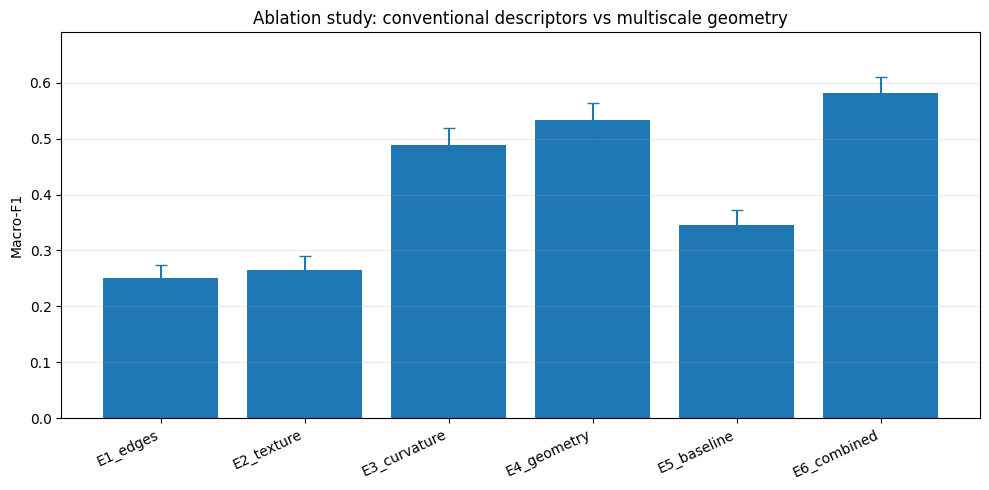

/content/painting-geometry/results/Figure_ablation_macroF1.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = ablation.copy()
x = np.arange(len(plot_df))
y = plot_df["macro_f1"].to_numpy()
yerr = np.vstack([
    y - plot_df["macro_f1_ci_low"].to_numpy(),
    plot_df["macro_f1_ci_high"].to_numpy() - y
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x, y)
ax.errorbar(x, y, yerr=yerr, fmt="none", capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["experiment"], rotation=25, ha="right")
ax.set_ylabel("Macro-F1")
ax.set_title("Ablation study: conventional descriptors vs multiscale geometry")
ax.set_ylim(0, min(1.0, max(0.2, float(plot_df["macro_f1_ci_high"].max()) + 0.08)))
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

fig_path = RESULTS_DIR / "Figure_ablation_macroF1.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(fig_path)


## 10. The decisive comparison: E6 combined vs E5 conventional baseline

Interpretation:

- If the 95% CI for \(\Delta F_1\) is entirely above zero, there is strong evidence that geometric descriptors add out-of-sample information to this baseline.
- If it crosses zero but the point estimate is positive, the effect is suggestive but not yet robust.
- If it is near zero or negative, classification should not be the central story; the project should pivot toward corpus geometry, artist-level distributions, and *The Starry Night* outlier analysis.


In [34]:
d = delta.iloc[0]
print(f"Δ Macro-F1 (E6 - E5): {d.delta_macro_f1:.4f}")
print(f"95% paired bootstrap CI: [{d.delta_ci_low:.4f}, {d.delta_ci_high:.4f}]")
print(f"Bootstrap one-sided p-like proportion P(Δ<=0): {d.bootstrap_p_improvement:.4f}")

if d.delta_ci_low > 0:
    decision = "GO: geometry adds robust incremental information."
elif d.delta_macro_f1 > 0:
    decision = "BORDERLINE: positive effect, but uncertainty includes zero."
else:
    decision = "PIVOT: no incremental classification advantage detected."

print("\nDecision:", decision)


Δ Macro-F1 (E6 - E5): 0.2359
95% paired bootstrap CI: [0.2012, 0.2720]
Bootstrap one-sided p-like proportion P(Δ<=0): 0.0000

Decision: GO: geometry adds robust incremental information.


## 11. Per-artist comparison: conventional baseline vs combined geometry


In [35]:
from sklearn.metrics import precision_recall_fscore_support

artists = sorted(preds["artist"].unique())
rows = []
for model in ["E5_baseline", "E6_combined"]:
    _, _, f1, support = precision_recall_fscore_support(
        preds["artist"], preds[model], labels=artists, zero_division=0
    )
    for a, score, n in zip(artists, f1, support):
        rows.append({"artist": a, "model": model, "f1": score, "support": int(n)})

per_artist = pd.DataFrame(rows)
pivot = per_artist.pivot(index="artist", columns="model", values="f1")
pivot["delta_E6_minus_E5"] = pivot["E6_combined"] - pivot["E5_baseline"]
display(pivot.sort_values("delta_E6_minus_E5", ascending=False))

pivot.to_csv(RESULTS_DIR / "per_artist_f1_comparison.csv")


model,E5_baseline,E6_combined,delta_E6_minus_E5
artist,,,
Monet,0.278481,0.601036,0.322555
Gauguin,0.280543,0.583333,0.302790
Degas,0.159574,0.462312,0.302737
Pissarro,0.235897,0.529412,0.293514
Renoir,0.417910,0.666667,0.248756
Cezanne,0.352941,0.599078,0.246137
Hassam,0.371681,0.579710,0.208029
Sargent,0.433628,0.597015,0.163387
VanGogh,0.468571,0.611111,0.142540


## 12. Confusion matrices for E5 and E6


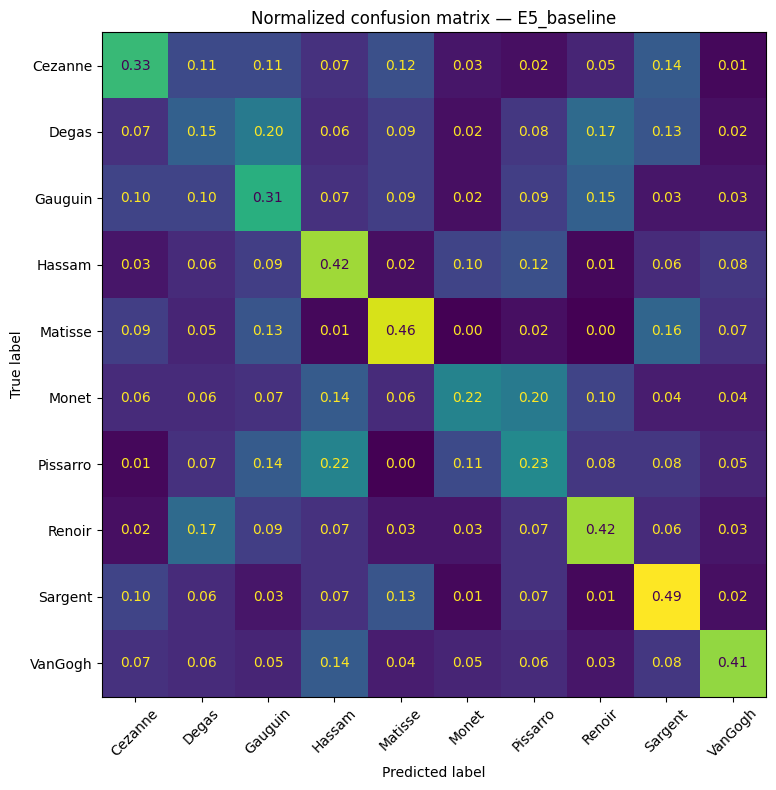

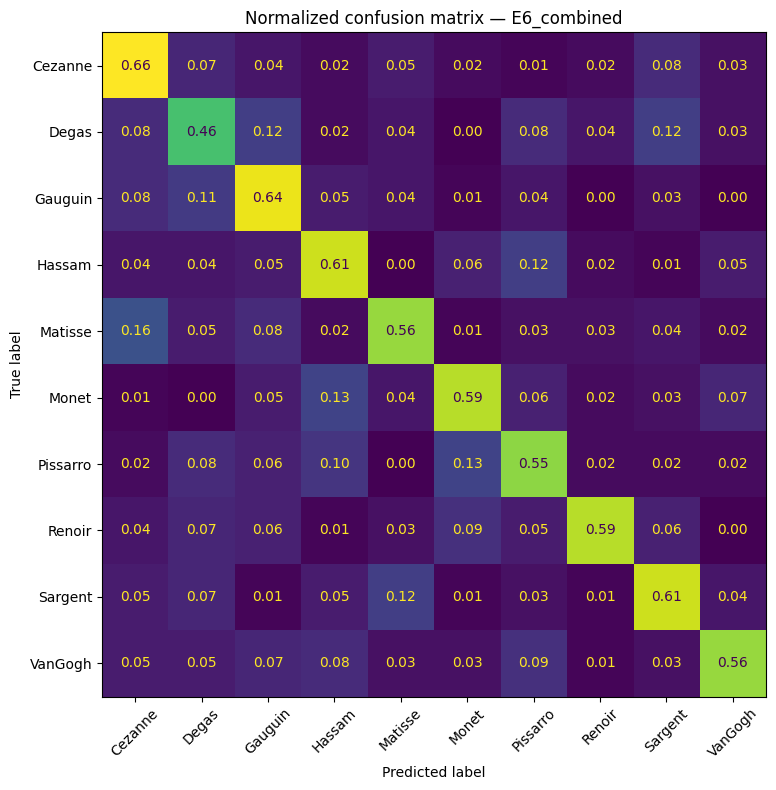

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for model in ["E5_baseline", "E6_combined"]:
    cm = confusion_matrix(preds["artist"], preds[model], labels=artists, normalize="true")
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=artists)
    disp.plot(ax=ax, xticks_rotation=45, values_format=".2f", colorbar=False)
    ax.set_title(f"Normalized confusion matrix — {model}")
    fig.tight_layout()
    path = RESULTS_DIR / f"Figure_confusion_{model}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


## 13. Package outputs for manuscript inspection

The ZIP contains feature tables, inferential statistics, ablation results, predictions, and the first figures. Download it from the Colab file browser or use the automatic download cell.


In [37]:
import shutil
archive = shutil.make_archive("/content/painting_geometry_first_results", "zip", RESULTS_DIR)
print("Archive:", archive)

try:
    from google.colab import files
    files.download(archive)
except Exception:
    print("Automatic Colab download unavailable; retrieve the ZIP manually:", archive)


Archive: /content/painting_geometry_first_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next experiment after this notebook

Do **not** tune the model aggressively before inspecting the ablation result. The scientific priority is to establish whether curvature contributes information under a controlled comparison.

If E6 > E5 robustly, the next notebook should test:

1. stability at 256 / 512 / 1024 px;
2. scale-specific ablations for \(\sigma=1,2,4,8\);
3. artist-level effect sizes and pairwise post-hoc comparisons;
4. *The Starry Night* position within the Van Gogh distribution.

If E6 does not improve E5, the same extracted geometric descriptors remain useful for a non-classification paper centered on comparative geometry and within-artist structure.
